# TensorBoard-Plots der Ablationsstudie

Dieses Notebook erzeugt die Plots fuer die Ablationsstudie des Fully-Joint-Trainings. Verwendet werden nur Hyperparameterkonfigurationen, die in allen vier Varianten vorkommen. Dadurch wird die Fully-Joint-Baseline nur mit den Seeds und Konfigurationen verglichen, die auch fuer die Ablationen vorhanden sind. Die Trial-Nummer wird nicht als Teil der Konfiguration verwendet, da sie zwischen den Suchlaeufen unterschiedlich nummeriert sein kann.

Panel-Reihenfolge:

- oben links: **Fully-Joint**
- oben rechts: **No Aux**
- unten links: **No Budget-Loss**
- unten rechts: **No Routing-Loss**


In [20]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
})


In [21]:
OUT_DIR_NAME = "figures_ablation"
# TensorBoard-Schritte sind 0-indiziert; step <= 99 entspricht 100 geloggten Epochen.
MAX_EPOCH = 99
REQUIRE_ALL_VARIANTS = True

VARIANTEN = [
    {"label": "Fully-Joint", "relative_root": Path("moe_runs/big_randomsearch/additive")},
    {"label": "No Aux", "relative_root": Path("moe_runs/ablation_no_aux_fullyjoint")},
    {"label": "No Budget-Loss", "relative_roots": [Path("moe_runs/ablation_no_budgetloss/additive"), Path("moe_runs/ablation_no_budgetloss")]},
    {"label": "No Routing-Loss", "relative_root": Path("moe_runs/ablation_no_routingloss")},
]

CONFIG_KEY_COLUMNS = [
    "seed",
    "expert_lr",
    "rejector_lr",
    "weight_decay",
    "temperature",
    "topk_noise_std",
    "topk_noise_start_epoch",
    "topk_noise_epochs",
    "batch_size",
    "threshold_r1",
    "threshold_r2",
]

VARIANT_LAYOUT = [
    ["Fully-Joint", "No Aux"],
    ["No Budget-Loss", "No Routing-Loss"],
]

VARIANT_PLOT_LABELS = {
    "Fully-Joint": "Fully-Joint",
    "No Aux": "ohne Auxiliary-Loss",
    "No Budget-Loss": "ohne Budget-Loss",
    "No Routing-Loss": "ohne Routing-Loss",
}


def finde_moe_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        kandidaten = (
            base,
            base / "moe",
            base / "single_pulse_classifier_training" / "moe",
            base / "WP2-1" / "single_pulse_classifier_training" / "moe",
        )
        for kandidat in kandidaten:
            if (kandidat / "moe_runs").exists():
                return kandidat
    raise FileNotFoundError("moe_runs konnte vom aktuellen Arbeitsverzeichnis aus nicht gefunden werden.")


MOE_ROOT = finde_moe_root()
OUT_DIR = MOE_ROOT / "plots" / OUT_DIR_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

MOE_ROOT, OUT_DIR


(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_ablation'))

In [22]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        warnings.warn(f"Konnte JSON nicht lesen: {path}")
        return {}


def dekodiere_float_token(token: str) -> str:
    return token.replace("p", ".").replace("em", "e-")


def parse_run_name(run_name: str) -> dict:
    muster = {
        "trial": r"trial(\d+)",
        "seed": r"seed(\d+)",
        "expert_lr": r"expertlr([0-9pem]+)",
        "rejector_lr": r"rejectorlr([0-9pem]+)",
        "weight_decay": r"wd([0-9pem]+)",
        "temperature": r"temp([0-9pem]+)",
        "topk_noise_std": r"topknoisestd([0-9pem]+)",
        "topk_noise_start_epoch": r"noisestart(\d+)",
        "topk_noise_epochs": r"noiseep(\d+)",
        "budget": r"budget([0-9pem]+)",
        "routing": r"routing([0-9pem]+)",
        "aux": r"aux([0-9pem]+)",
        "aux_warmup": r"auxwarmup(\d+)",
    }
    daten = {}
    for name, pattern in muster.items():
        match = re.search(pattern, run_name)
        if not match:
            daten[name] = np.nan
            continue
        value = match.group(1)
        if name in {"trial", "seed", "aux_warmup", "topk_noise_start_epoch", "topk_noise_epochs"}:
            daten[name] = int(value)
        else:
            daten[name] = float(dekodiere_float_token(value))
    return daten


def canonical_number(value):
    if value is None:
        return np.nan
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    return value


def normalize_config_value(value):
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, (np.floating, float)):
        return format(float(value), ".17g")
    if isinstance(value, (np.integer, int)):
        return int(value)
    return value


def make_config_key(row: pd.Series) -> str:
    return json.dumps(
        {column: normalize_config_value(row[column]) for column in CONFIG_KEY_COLUMNS},
        sort_keys=True,
        separators=(",", ":"),
    )


def bool_eq(value, expected: bool) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and np.isnan(value):
        return False
    return bool(value) is expected


def status_priority(status: str) -> int:
    return {"completed": 3, "running": 2, "interrupted": 1}.get(status, 0)


def read_run_status(run_dir: Path) -> str:
    result = read_json(run_dir / "randomsearch_result.json")
    return result.get("status", "unknown")


def is_canonical_ablation_run(row: pd.Series) -> bool:
    if row["variant"] == "Fully-Joint":
        return (
            row["expert_aux_loss_weight"] == 1.0
            and row["expert_aux_loss_epochs"] == 100
            and bool_eq(row["only_aux_warmup"], False)
            and row["aux_loss_mode"] == "additive"
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 2.0
        )
    if row["variant"] == "No Aux":
        return (
            row["expert_aux_loss_weight"] == 0.0
            and row["expert_aux_loss_epochs"] == 100
            and bool_eq(row["only_aux_warmup"], False)
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 2.0
        )
    if row["variant"] == "No Budget-Loss":
        return (
            row["expert_aux_loss_weight"] == 1.0
            and row["expert_aux_loss_epochs"] == 100
            and bool_eq(row["only_aux_warmup"], False)
            and row["budget_loss_weight"] == 0.0
            and row["routing_loss_weight"] == 2.0
        )
    if row["variant"] == "No Routing-Loss":
        return (
            row["expert_aux_loss_weight"] == 1.0
            and row["expert_aux_loss_epochs"] == 100
            and bool_eq(row["only_aux_warmup"], False)
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 0.0
        )
    return False


def speichere_abbildung(fig, name: str):
    path = OUT_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(path)


In [23]:
def load_tensorboard_scalars() -> tuple[pd.DataFrame, pd.DataFrame]:
    scalar_rows = []
    run_rows = []

    for variant_spec in VARIANTEN:
        label = variant_spec["label"]
        if "relative_roots" in variant_spec:
            relative_roots = variant_spec["relative_roots"]
        else:
            relative_roots = [variant_spec["relative_root"]]

        for relative_root in relative_roots:
            variant_root = MOE_ROOT / relative_root
            if not variant_root.exists():
                warnings.warn(f"Variante fehlt: {variant_root}")
                continue

            for tensorboard_dir in sorted(variant_root.glob("*/tensorboard")):
                run_dir = tensorboard_dir.parent
                event_files = sorted(tensorboard_dir.glob("events.out.tfevents.*"))
                if not event_files:
                    continue

                try:
                    acc = EventAccumulator(str(tensorboard_dir), size_guidance={"scalars": 0})
                    acc.Reload()
                except Exception as exc:
                    warnings.warn(f"TensorBoard-Run konnte nicht gelesen werden: {tensorboard_dir} ({exc})")
                    continue

                tags = set(acc.Tags().get("scalars", []))
                parsed = parse_run_name(run_dir.name)
                cfg = read_json(run_dir / "sampled_config.json")
                training = cfg.get("training", {})
                model = cfg.get("model", {})
                loader = cfg.get("loader", {})
                inference = cfg.get("inference", {})
                run_id = f"{label}/{run_dir.name}"
                n_points = 0

                for tag in sorted(tags):
                    for event in acc.Scalars(tag):
                        scalar_rows.append({
                            "variant": label,
                            "run_id": run_id,
                            "run": run_dir.name,
                            "run_dir": str(run_dir),
                            "tag": tag,
                            "step": event.step,
                            "value": event.value,
                            "wall_time": event.wall_time,
                        })
                        n_points += 1

                status = read_run_status(run_dir)
                run_rows.append({
                    "variant": label,
                    "run_id": run_id,
                    "run": run_dir.name,
                    "run_dir": str(run_dir),
                    "status": status,
                    "status_priority": status_priority(status),
                    "n_points": n_points,
                    "trial": canonical_number(parsed.get("trial")),
                    "seed": canonical_number(cfg.get("seed", parsed.get("seed"))),
                    "expert_lr": canonical_number(training.get("expert_learning_rate", parsed.get("expert_lr"))),
                    "rejector_lr": canonical_number(training.get("rejector_learning_rate", parsed.get("rejector_lr"))),
                    "weight_decay": canonical_number(training.get("weight_decay", parsed.get("weight_decay"))),
                    "budget_loss_weight": canonical_number(training.get("budget_loss_weight", parsed.get("budget"))),
                    "routing_loss_weight": canonical_number(training.get("routing_loss_weight", parsed.get("routing"))),
                    "temperature": canonical_number(model.get("temperature", parsed.get("temperature"))),
                    "topk_noise_std": canonical_number(training.get("topk_noise_std", parsed.get("topk_noise_std"))),
                    "topk_noise_start_epoch": canonical_number(training.get("topk_noise_start_epoch", parsed.get("topk_noise_start_epoch"))),
                    "topk_noise_epochs": canonical_number(training.get("topk_noise_epochs", parsed.get("topk_noise_epochs"))),
                    "batch_size": canonical_number(loader.get("batch_size")),
                    "threshold_r1": canonical_number(inference.get("threshold_r1")),
                    "threshold_r2": canonical_number(inference.get("threshold_r2")),
                    "expert_aux_loss_weight": canonical_number(training.get("expert_aux_loss_weight", parsed.get("aux"))),
                    "expert_aux_loss_epochs": canonical_number(training.get("expert_aux_loss_epochs", parsed.get("auxep"))),
                    "only_aux_warmup": bool(training.get("only_aux_warmup", parsed.get("only_aux_warmup", False))),
                    "aux_loss_mode": training.get("aux_loss_mode", parsed.get("aux_loss_mode")),
                })

    scalars = pd.DataFrame(scalar_rows)
    runs = pd.DataFrame(run_rows)
    if runs.empty:
        raise RuntimeError("Keine TensorBoard-Runs gefunden.")

    return scalars, runs


scalars, runs = load_tensorboard_scalars()
print(f"Geladene Runs: {len(runs)}")
print(f"Geladene Scalar-Punkte: {len(scalars):,}")
display(runs.groupby(["variant", "status"], dropna=False).size().rename("runs").reset_index())


Geladene Runs: 44
Geladene Scalar-Punkte: 376,427


,variant,status,runs
0,Fully-Joint,completed,15
1,Fully-Joint,interrupted,1
2,Fully-Joint,running,5
3,No Aux,completed,3
4,No Aux,interrupted,8
5,No Budget-Loss,completed,4
6,No Budget-Loss,running,1
7,No Routing-Loss,completed,2
8,No Routing-Loss,interrupted,2
9,No Routing-Loss,running,3


In [24]:
MATCH_VARIANTS = [variant_spec["label"] for variant_spec in VARIANTEN]

runs["config_key"] = runs.apply(make_config_key, axis=1)
runs["canonical_variant_run"] = runs.apply(is_canonical_ablation_run, axis=1)

if not scalars.empty:
    val_topk = scalars.loc[scalars["tag"] == "val_topk/accuracy"]
    if MAX_EPOCH is not None:
        val_topk = val_topk.loc[val_topk["step"] <= MAX_EPOCH]
    best_topk = val_topk.groupby("run_id")["value"].max()
    runs["best_val_topk_accuracy"] = runs["run_id"].map(best_topk)
else:
    runs["best_val_topk_accuracy"] = np.nan


def select_shared_config_runs(
    scalars_all: pd.DataFrame,
    runs_all: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    canonical_runs = runs_all.loc[runs_all["canonical_variant_run"]].copy()

    duplicate_mask = canonical_runs.duplicated(["variant", "config_key"], keep=False)
    duplicate_runs = canonical_runs.loc[duplicate_mask].sort_values(["variant", "config_key", "run"])

    sort_columns = ["variant", "config_key", "status_priority", "n_points", "best_val_topk_accuracy", "run"]
    canonical_runs = canonical_runs.sort_values(sort_columns, ascending=[True, True, False, False, False, True])
    canonical_runs = canonical_runs.drop_duplicates(["variant", "config_key"], keep="first")

    counts = canonical_runs.groupby("config_key")["variant"].nunique()
    shared_keys = set(counts.loc[counts == len(MATCH_VARIANTS)].index)
    duplicate_runs = duplicate_runs.loc[duplicate_runs["config_key"].isin(shared_keys)]
    matched_runs = canonical_runs.loc[canonical_runs["config_key"].isin(shared_keys)].copy()

    if matched_runs.empty:
        raise RuntimeError("Keine gemeinsame Ablationskonfiguration in allen Varianten gefunden.")

    order_frame = (
        matched_runs.loc[matched_runs["variant"] == "Fully-Joint", ["config_key", "best_val_topk_accuracy", "seed"]]
        .rename(columns={"best_val_topk_accuracy": "fully_joint_best"})
        .sort_values(["fully_joint_best", "seed"], ascending=[False, True])
    )
    config_order = order_frame["config_key"].tolist()
    config_ids = {key: f"A{i:02d}" for i, key in enumerate(config_order, start=1)}

    matched_runs["config_id"] = matched_runs["config_key"].map(config_ids)
    matched_runs["plot_label"] = matched_runs.apply(lambda row: f"Seed: {int(row['seed'])}", axis=1)
    matched_runs["config_label"] = matched_runs.apply(
        lambda row: f"{row['config_id']} | Seed {int(row['seed'])} | lrE={row['expert_lr']:.2e} | lrR={row['rejector_lr']:.2e} | wd={row['weight_decay']:.0e}",
        axis=1,
    )

    shared_configs = (
        matched_runs[["config_key", "config_id", "config_label", "plot_label", *CONFIG_KEY_COLUMNS]]
        .drop_duplicates("config_key")
        .sort_values("config_id")
    )

    scalars_selected = scalars_all.merge(
        matched_runs[["run_id", "config_key", "config_id", "config_label", "plot_label"]],
        on="run_id",
        how="inner",
    )
    return scalars_selected, matched_runs, shared_configs, duplicate_runs


scalars_all = scalars
runs_all = runs
scalars, runs, shared_configs, duplicate_runs = select_shared_config_runs(scalars_all, runs_all)

runs_all.to_csv(OUT_DIR / "ablation_summary_all.csv", index=False)
runs.to_csv(OUT_DIR / "ablation_summary_shared.csv", index=False)
shared_configs.to_csv(OUT_DIR / "ablation_shared_configs.csv", index=False)

print(f"Kanonische Runs: {runs_all['canonical_variant_run'].sum()} von {len(runs_all)}")
print(f"Gemeinsame Configs: {shared_configs['config_key'].nunique()}")
print(f"Verwendete Runs: {len(runs)}")
display(runs.groupby("variant").size().rename("runs").reset_index())

if not duplicate_runs.empty:
    print("Doppelte kanonische Runs vor der Auswahl:")
    display(duplicate_runs[["variant", "seed", "trial", "expert_lr", "rejector_lr", "weight_decay", "status", "run"]])

display(shared_configs[["config_id", "seed", "expert_lr", "rejector_lr", "weight_decay"]])
display(runs.sort_values(["config_id", "variant"])[["config_id", "variant", "seed", "status", "run", "best_val_topk_accuracy"]])


Kanonische Runs: 40 von 44
Gemeinsame Configs: 5
Verwendete Runs: 20


,variant,runs
0,Fully-Joint,5
1,No Aux,5
2,No Budget-Loss,5
3,No Routing-Loss,5


Doppelte kanonische Runs vor der Auswahl:


,variant,seed,trial,expert_lr,rejector_lr,weight_decay,status,run
22,No Aux,43,0,0.000001,0.000025,0.000001,interrupted,joint_moe_worker0_trial0_seed43_expertlr1p305e...
27,No Aux,43,1,0.000001,0.000025,0.000001,interrupted,joint_moe_worker0_trial1_seed43_expertlr1p305e...


,config_id,seed,expert_lr,rejector_lr,weight_decay
7,A01,100042,0.000208,0.000002,0.000001
20,A02,300045,0.000340,0.000006,0.000100
0,A03,42,0.000083,0.000001,0.000010
5,A04,44,0.000017,0.000012,0.000000
3,A05,43,0.000001,0.000025,0.000001


,config_id,variant,seed,status,run,best_val_topk_accuracy
7,A01,Fully-Joint,100042,completed,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.881284
28,A01,No Aux,100042,completed,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.865054
35,A01,No Budget-Loss,100042,completed,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.779245
40,A01,No Routing-Loss,100042,completed,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.841134
20,A02,Fully-Joint,300045,running,joint_moe_worker3_trial3_seed300045_expertlr0p...,0.879557
30,A02,No Aux,300045,completed,joint_moe_worker3_trial0_seed300045_expertlr0p...,0.850208
36,A02,No Budget-Loss,300045,running,joint_moe_worker3_trial0_seed300045_expertlr0p...,0.862700
42,A02,No Routing-Loss,300045,completed,joint_moe_worker3_trial0_seed300045_expertlr0p...,0.856312
0,A03,Fully-Joint,42,completed,joint_moe_worker0_trial0_seed42_expertlr8p285e...,0.877587
21,A03,No Aux,42,completed,joint_moe_worker0_trial0_seed42_expertlr8p285e...,0.842430


In [ ]:
def tag_frame(tag: str, variant: str | None = None) -> pd.DataFrame:
    frame = scalars.loc[scalars["tag"] == tag].copy()
    if MAX_EPOCH is not None:
        frame = frame.loc[frame["step"] <= MAX_EPOCH]
    if variant is not None:
        frame = frame.loc[frame["variant"] == variant]
    return frame


CONFIG_ORDER = shared_configs["config_key"].tolist()
CONFIG_LABELS = shared_configs.set_index("config_key")["plot_label"].to_dict()
CONFIG_COLORS = {
    key: color
    for key, color in zip(CONFIG_ORDER, plt.cm.tab10(np.linspace(0, 1, max(len(CONFIG_ORDER), 1))))
}


def markiere_maximum(ax, frame: pd.DataFrame):
    if frame.empty or frame["value"].dropna().empty:
        return
    max_value = frame["value"].max()
    yaxis_transform = ax.get_yaxis_transform()
    ax.plot(
        [-0.028, 0.0],
        [max_value, max_value],
        transform=yaxis_transform,
        color="0.45",
        linewidth=1.8,
        solid_capstyle="butt",
        clip_on=False,
        zorder=5,
    )
    ax.text(
        -0.035,
        max_value,
        f"{max_value:.4f}",
        transform=yaxis_transform,
        ha="right",
        va="center",
        color="0.35",
        fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.8},
        clip_on=False,
    )


def plot_runs(ax, variant: str, tag: str, ylabel: str, title: str, mark_maximum: bool = False):
    frame = tag_frame(tag, variant)
    for config_key in CONFIG_ORDER:
        run_frame = frame.loc[frame["config_key"] == config_key].sort_values("step")
        if run_frame.empty:
            continue
        ax.plot(
            run_frame["step"],
            run_frame["value"],
            linewidth=1.35,
            alpha=0.92,
            color=CONFIG_COLORS[config_key],
            label=CONFIG_LABELS[config_key],
        )
    if mark_maximum:
        markiere_maximum(ax, frame)
    ax.set_title(title)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(ylabel)


def add_common_legend(fig, ax, ncol: int = 1, x: float = 0.84, fontsize: float = 12.0):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(x, 0.5),
            fontsize=fontsize,
            ncol=ncol,
            borderaxespad=0.0,
            labelspacing=0.65,
            handlelength=2.4,
            handletextpad=0.7,
        )


def set_epoch_xlim(axes, tag: str):
    max_step = tag_frame(tag)["step"].max()
    right = MAX_EPOCH if MAX_EPOCH is not None else max_step
    if pd.notna(right):
        for ax in np.ravel(axes):
            ax.set_xlim(0, right)


def plot_ablation_grid(tag: str, ylabel: str, title: str, filename: str, y_limits=None, mark_maximum: bool = False):
    fig, axes = plt.subplots(2, 2, figsize=(15, 8.4), sharex=True, sharey=True)
    for row_idx, row in enumerate(VARIANT_LAYOUT):
        for col_idx, variant in enumerate(row):
            ax = axes[row_idx, col_idx]
            plot_runs(ax, variant, tag, ylabel, VARIANT_PLOT_LABELS.get(variant, variant), mark_maximum=mark_maximum)
            if y_limits is not None:
                ax.set_ylim(*y_limits)
    set_epoch_xlim(axes, tag)
    fig.suptitle(title, y=1.02)
    add_common_legend(fig, axes[0, 0], x=0.835, fontsize=12.0)
    fig.tight_layout(rect=(0, 0, 0.815, 1))
    speichere_abbildung(fig, filename)
    plt.show()


## Top-k-Validierungsgenauigkeit


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_ablation/ablation_val_topk_accuracy.png


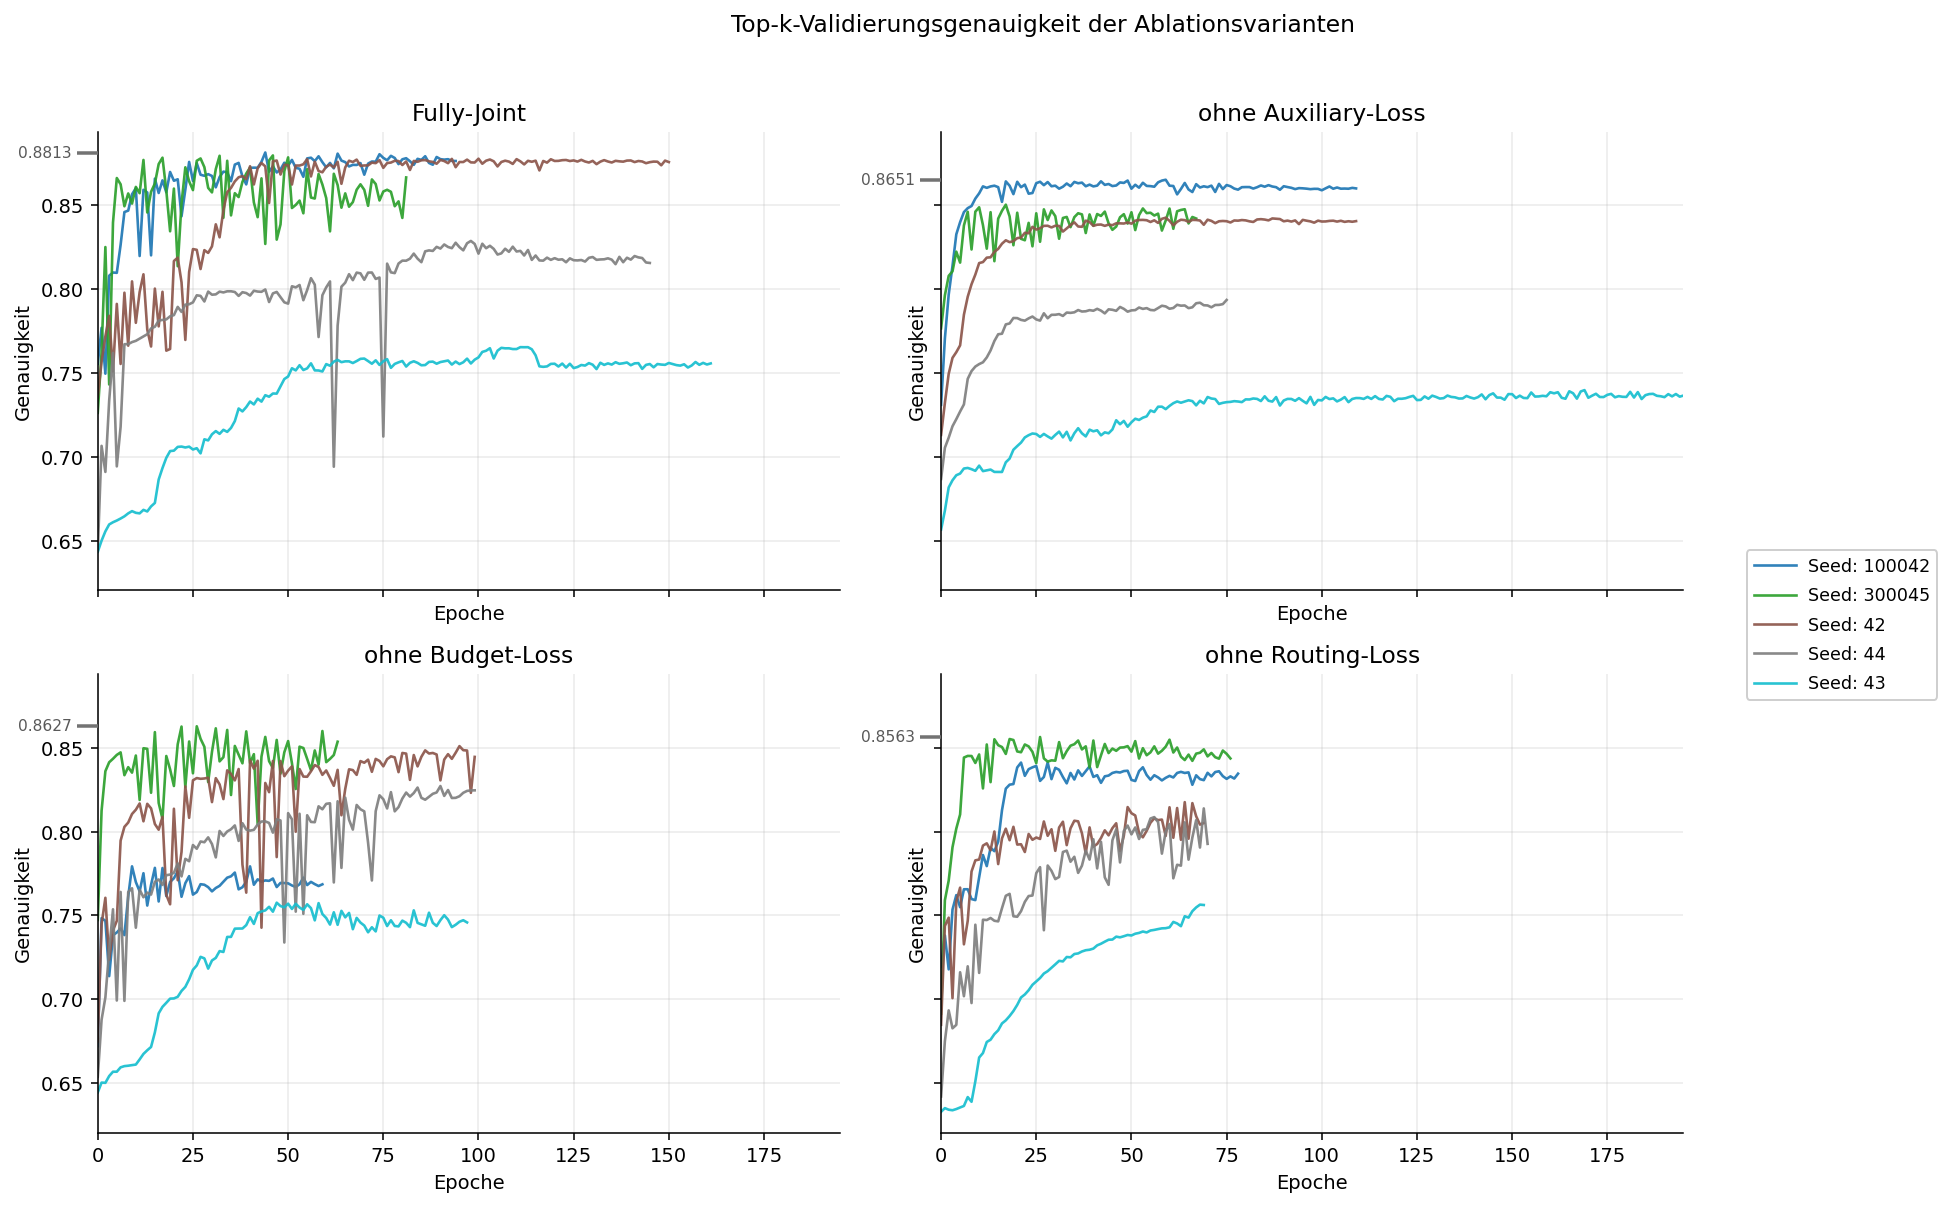

In [26]:
plot_ablation_grid(
    "val_topk/accuracy",
    "Genauigkeit",
    "Top-k-Validierungsgenauigkeit der Ablationsvarianten",
    "ablation_val_topk_accuracy.png",
    mark_maximum=True,
)


## Budgetierte Validierungsobergrenze


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_ablation/ablation_val_budgeted_upper_bound.png


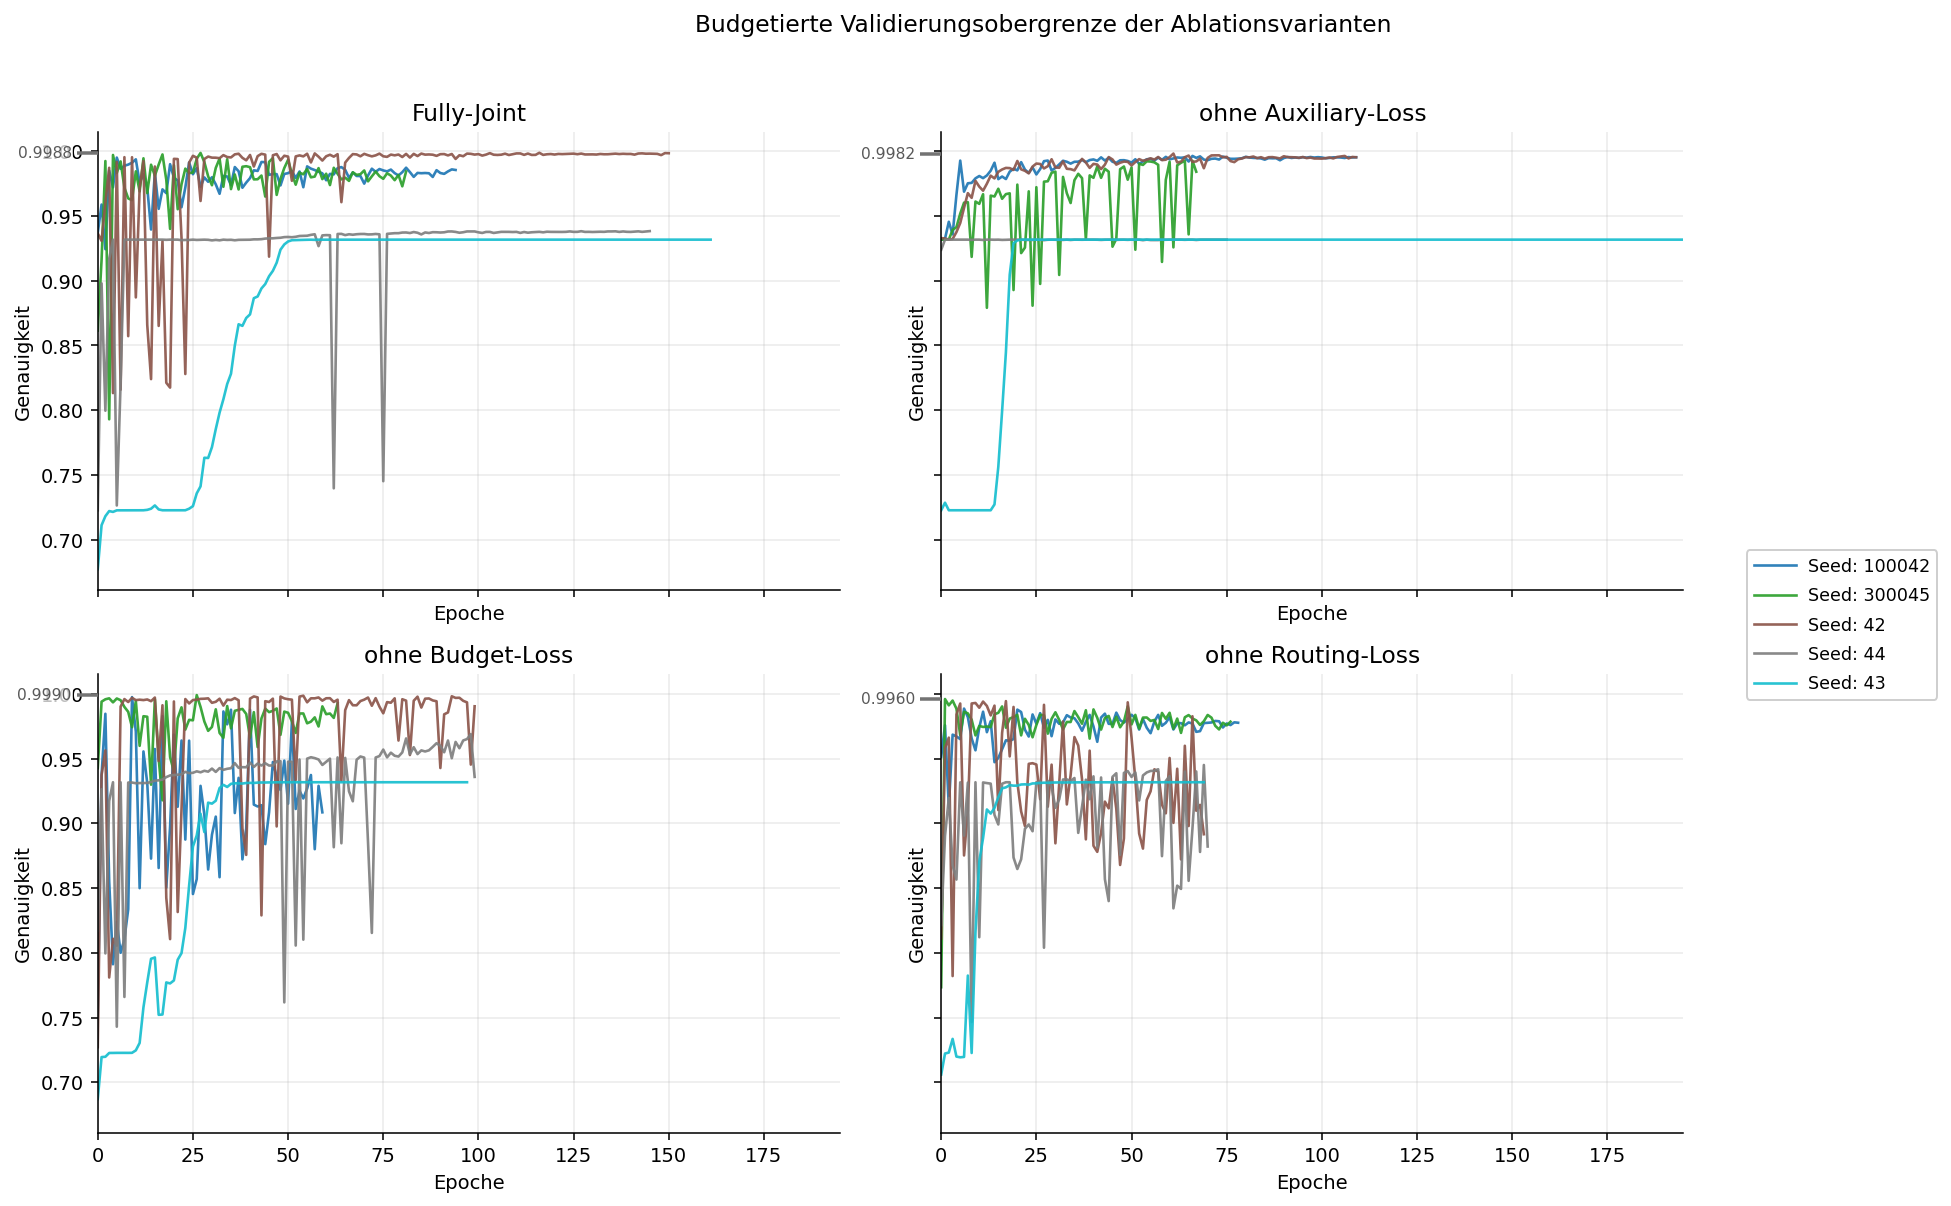

In [27]:
plot_ablation_grid(
    "val_budgeted_upper_bound",
    "Genauigkeit",
    "Budgetierte Validierungsobergrenze der Ablationsvarianten",
    "ablation_val_budgeted_upper_bound.png",
    mark_maximum=True,
)


## Validierungsgenauigkeiten der Klassifikatoren


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_ablation/ablation_val_expert_small_accuracy.png


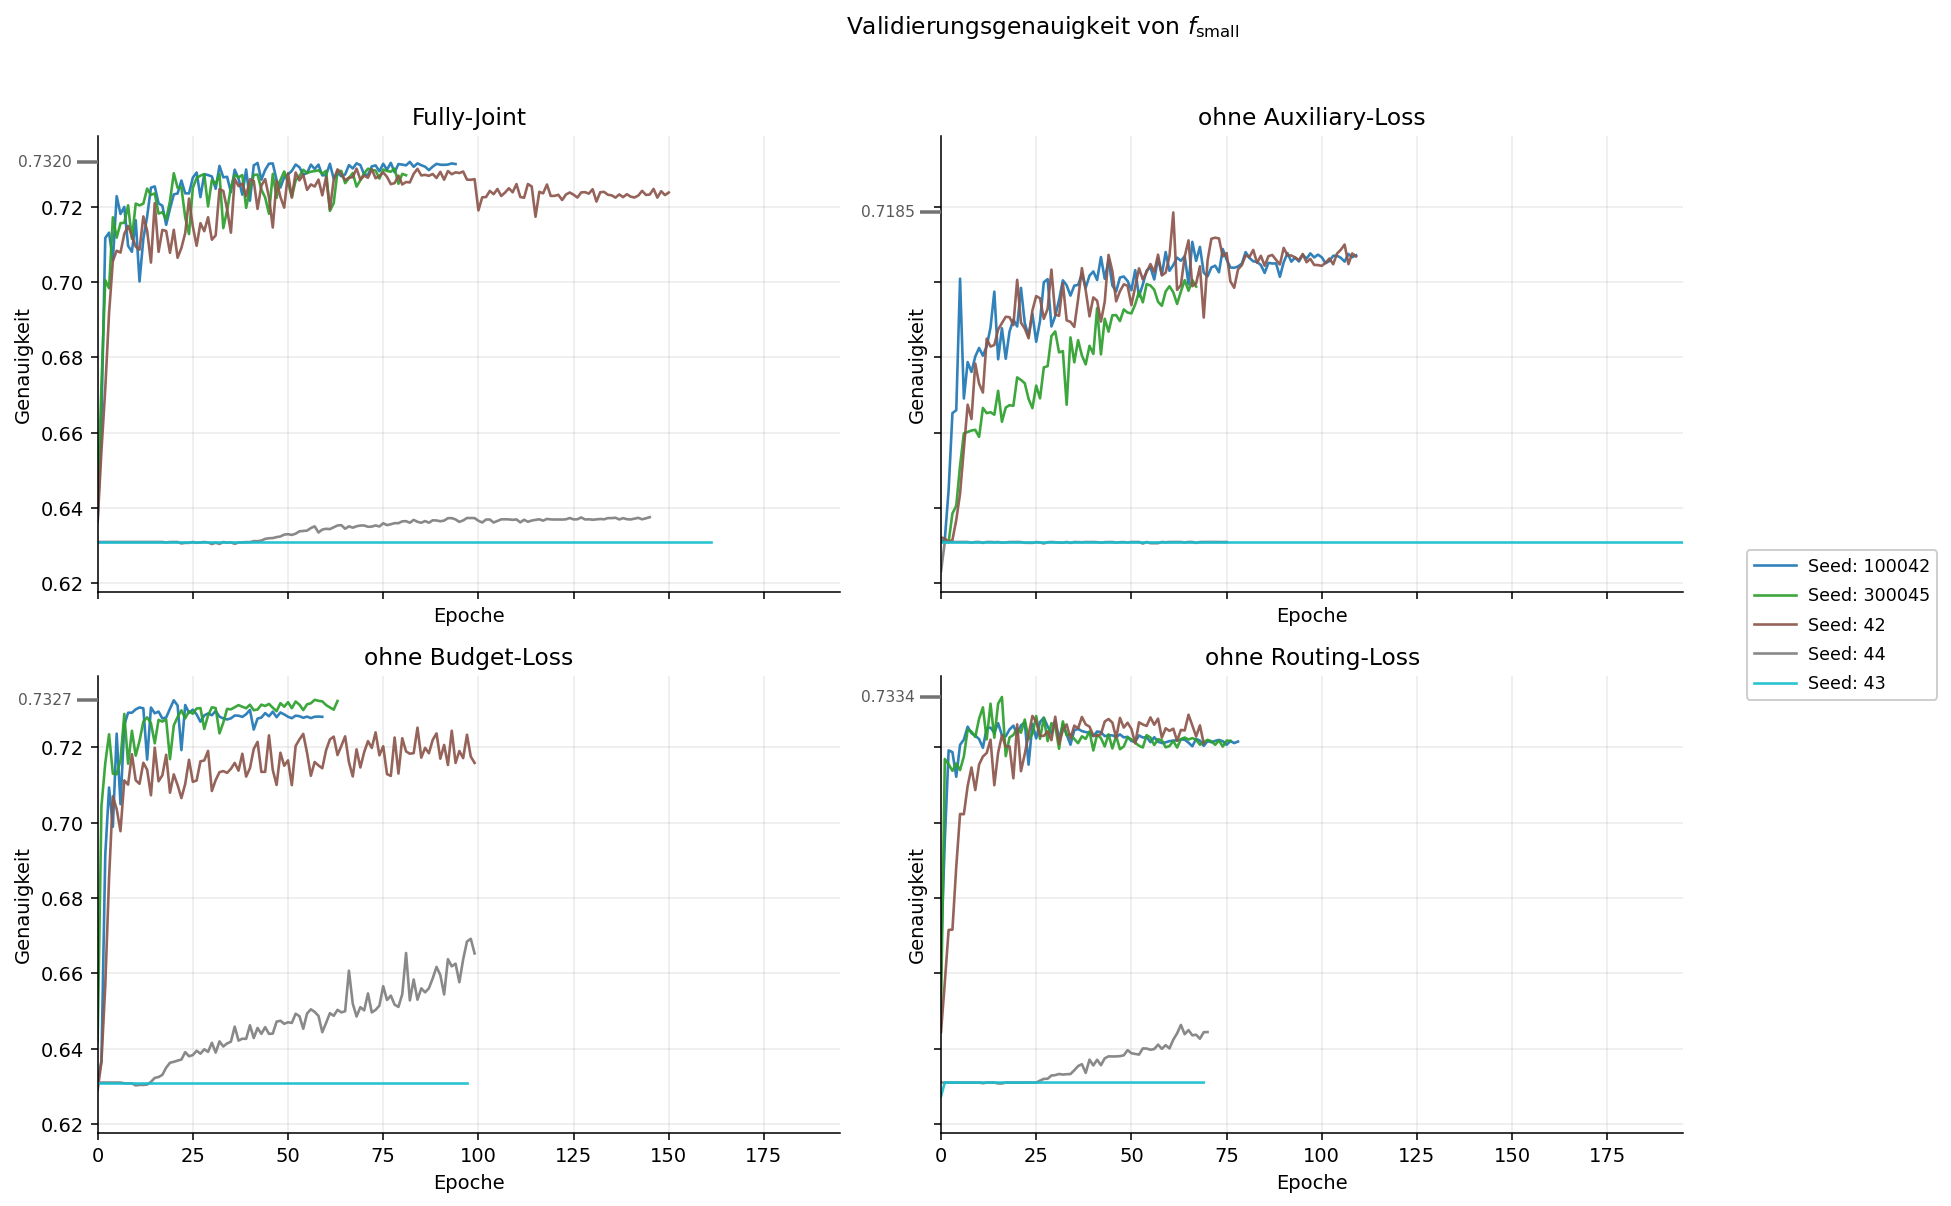

In [28]:
plot_ablation_grid(
    "val_expert/small_accuracy",
    "Genauigkeit",
    "Validierungsgenauigkeit von $f_{\mathrm{small}}$",
    "ablation_val_expert_small_accuracy.png",
    mark_maximum=True,
)


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_ablation/ablation_val_expert_mid_accuracy.png


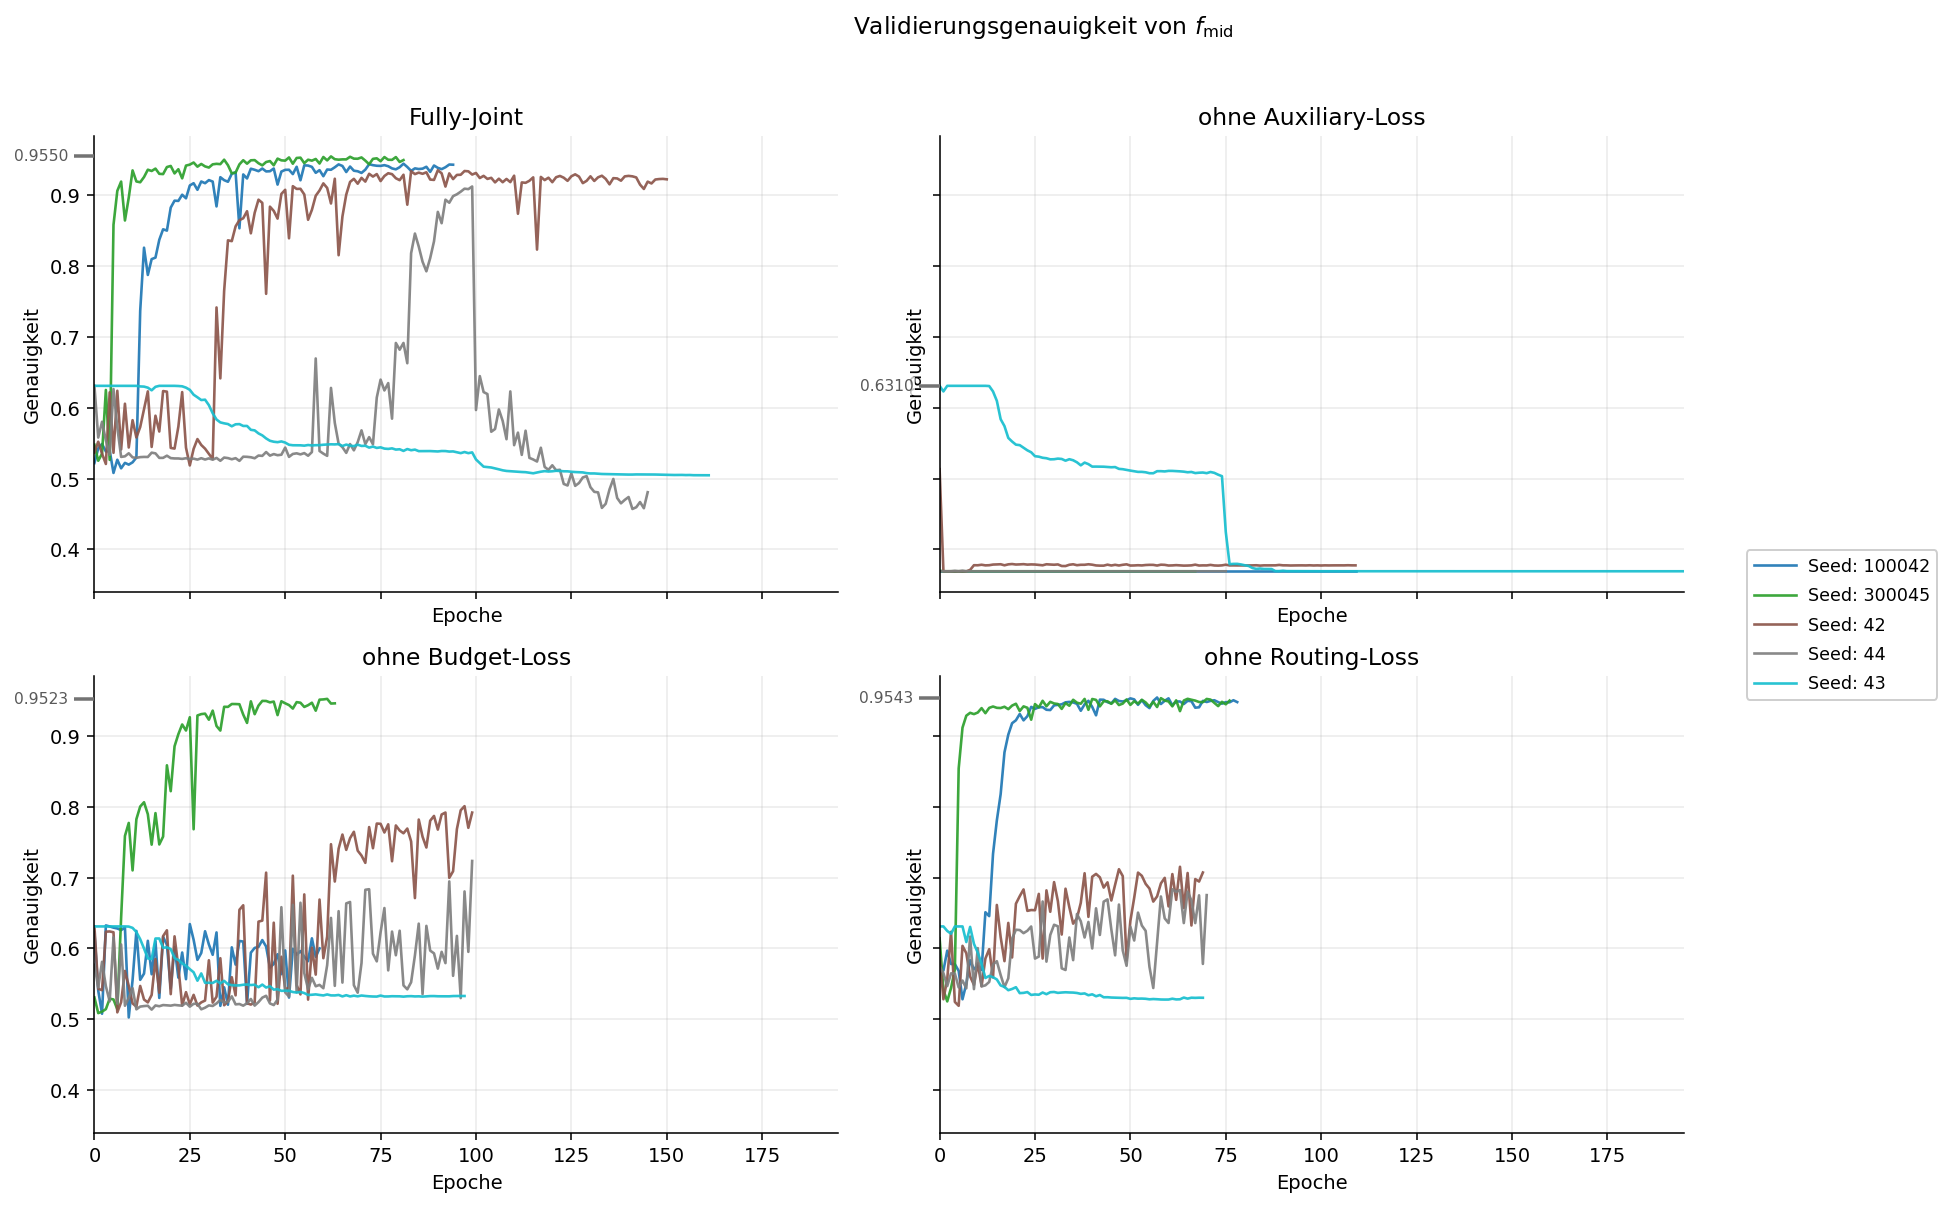

In [29]:
plot_ablation_grid(
    "val_expert/mid_accuracy",
    "Genauigkeit",
    "Validierungsgenauigkeit von $f_{\mathrm{mid}}$",
    "ablation_val_expert_mid_accuracy.png",
    mark_maximum=True,
)


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_ablation/ablation_val_expert_large_accuracy.png


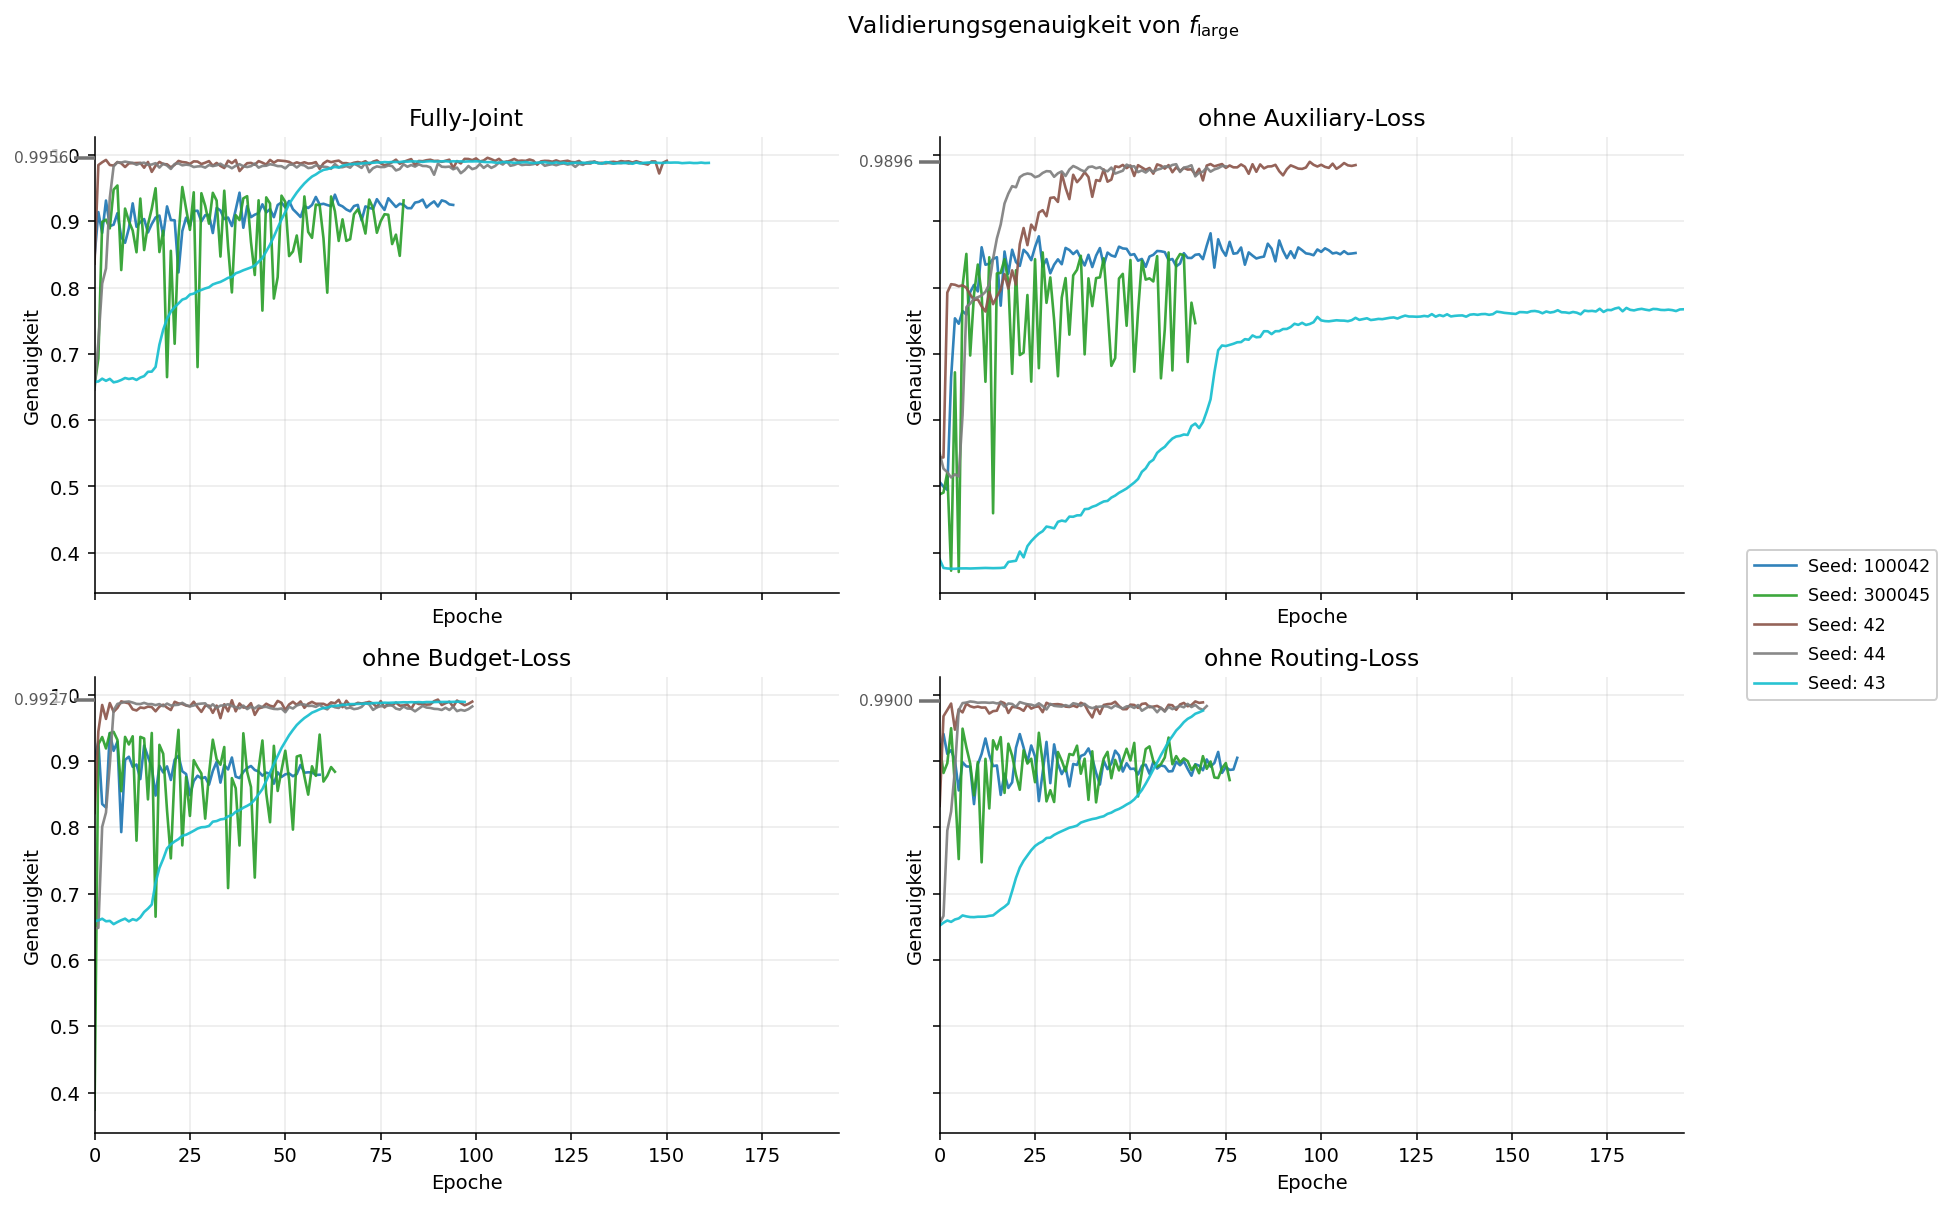

In [30]:
plot_ablation_grid(
    "val_expert/large_accuracy",
    "Genauigkeit",
    "Validierungsgenauigkeit von $f_{\mathrm{large}}$",
    "ablation_val_expert_large_accuracy.png",
    mark_maximum=True,
)


## Validierungsgenauigkeiten: Fully-Joint und ohne Auxiliary-Loss


In [ ]:
def plot_fully_joint_vs_no_aux_grid(
    tag: str,
    ylabel: str,
    title: str,
    filename: str,
    y_limits=None,
    mark_maximum: bool = False,
):
    variants = ["Fully-Joint", "No Aux"]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharex=True, sharey=True)

    for ax, variant in zip(axes, variants):
        plot_runs(
            ax,
            variant,
            tag,
            ylabel,
            VARIANT_PLOT_LABELS.get(variant, variant),
            mark_maximum=mark_maximum,
        )
        if y_limits is not None:
            ax.set_ylim(*y_limits)

    set_epoch_xlim(axes, tag)
    fig.suptitle(title, y=1.02)
    add_common_legend(fig, axes[0], x=0.835, fontsize=9.0)
    fig.tight_layout(rect=(0, 0, 0.815, 1))
    speichere_abbildung(fig, filename)
    plt.show()


In [ ]:
plot_fully_joint_vs_no_aux_grid(
    "val_expert/small_accuracy",
    "Genauigkeit",
    "Validierungsgenauigkeit von $f_{\mathrm{small}}$",
    "ablation_val_expert_small_accuracy_fullyjoint_no_aux.png",
    y_limits=(0.35, 1.02),
    mark_maximum=False,
)


In [ ]:
plot_fully_joint_vs_no_aux_grid(
    "val_expert/mid_accuracy",
    "Genauigkeit",
    "Validierungsgenauigkeit von $f_{\mathrm{mid}}$",
    "ablation_val_expert_mid_accuracy_fullyjoint_no_aux.png",
    y_limits=(0.35, 1.02),
    mark_maximum=False,
)


In [ ]:
plot_fully_joint_vs_no_aux_grid(
    "val_expert/large_accuracy",
    "Genauigkeit",
    "Validierungsgenauigkeit von $f_{\mathrm{large}}$",
    "ablation_val_expert_large_accuracy_fullyjoint_no_aux.png",
    y_limits=(0.35, 1.02),
    mark_maximum=False,
)


## Val-Hard-Usages ohne Budget-Loss


In [ ]:
def plot_no_budgetloss_val_hard_usages():
    variant = "No Budget-Loss"
    tags = [
        ("val_hard/usage_small", "$f_{\mathrm{small}}$"),
        ("val_hard/usage_mid", "$f_{\mathrm{mid}}$"),
        ("val_hard/usage_large", "$f_{\mathrm{large}}$"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)

    for ax, (tag, title) in zip(axes, tags):
        plot_runs(ax, variant, tag, "Nutzungsanteil", title, mark_maximum=False)
        ax.set_ylim(0, 1.02)

    max_step = tag_frame("val_hard/usage_small", variant)["step"].max()
    right = MAX_EPOCH if MAX_EPOCH is not None else max_step
    if pd.notna(right):
        for ax in axes:
            ax.set_xlim(0, right)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.03),
            ncol=len(labels),
            fontsize=9.0,
            frameon=True,
            framealpha=0.95,
            handlelength=2.4,
            columnspacing=1.4,
        )

    fig.suptitle("Val-Hard-Nutzungsanteile ohne Budget-Loss", y=1.03)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    speichere_abbildung(fig, "ablation_no_budgetloss_val_hard_usages.png")
    plt.show()


plot_no_budgetloss_val_hard_usages()
